## Practical Homework 3 - Deep Learning


### Student Name - Ruman Sidhu <3

## 1. Setup and Data Loading
Import required libraries and load the bird spectrogram dataset from the HDF5 file.

In [30]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# load the data
f = h5py.File('bird_spectrograms.hdf5', 'r')

# check what's inside
print(list(f.keys()))

['amecro', 'amerob', 'bewwre', 'bkcchi', 'daejun', 'houfin', 'houspa', 'norfli', 'rewbla', 'sonspa', 'spotow', 'whcspa']


In [31]:
for key in f.keys():
    print(key, f[key].shape)

amecro (128, 517, 66)
amerob (128, 517, 172)
bewwre (128, 517, 144)
bkcchi (128, 517, 45)
daejun (128, 517, 125)
houfin (128, 517, 84)
houspa (128, 517, 630)
norfli (128, 517, 37)
rewbla (128, 517, 187)
sonspa (128, 517, 263)
spotow (128, 517, 137)
whcspa (128, 517, 91)


## 2. Binary Species Selection and EDA
Load the two selected species- House Sparrow and White-crowned Sparrow- and visualize a sample spectrogram from each to understand the data structure.

House Sparrow shape: (128, 517, 630)
White-crowned Sparrow shape: (128, 517, 91)


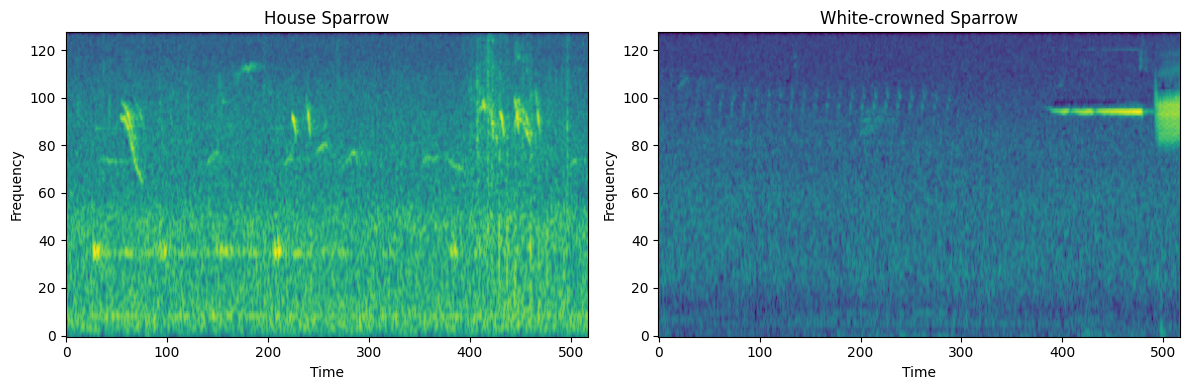

In [32]:
# load binary species
houspa = np.array(f['houspa'])  # house sparrow
whcspa = np.array(f['whcspa'])  # white-crowned sparrow

print("House Sparrow shape:", houspa.shape)
print("White-crowned Sparrow shape:", whcspa.shape)

# visualize one spectrogram from each
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(houspa[:, :, 0], aspect='auto', origin='lower')
axes[0].set_title('House Sparrow')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Frequency')

axes[1].imshow(whcspa[:, :, 0], aspect='auto', origin='lower')
axes[1].set_title('White-crowned Sparrow')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 3. Preprocessing and Train/Test Split
Transpose arrays to sample-first format, normalize pixel values to [0, 1], add a channel dimension for CNN compatibility, and perform a stratified 80/20 split to preserve class proportions.

In [33]:
# Transpose 
houspa_t = np.transpose(houspa, (2, 0, 1))   # (630, 128, 517)
whcspa_t = np.transpose(whcspa, (2, 0, 1))   # (91, 128, 517)

# Now concatenate along axis=0 (samples axis)
X = np.concatenate([houspa_t, whcspa_t], axis=0)   # (721, 128, 517)

y = np.concatenate([
    np.zeros(len(houspa_t)),    # House Sparrow = 0
    np.ones(len(whcspa_t))      # White-crowned Sparrow = 1
])

# Normalize
X = X.astype("float32") / 255.0

# Add channel dimension
X = X[..., np.newaxis]   # (721, 128, 517, 1)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train shape: (576, 128, 517, 1)
X_test shape: (145, 128, 517, 1)
y_train: (576,)
y_test: (145,)


## 4. Binary CNN Architecture v1
Build a baseline CNN with two convolutional blocks followed by a dense layer. Class weights are applied to address the 7:1 class imbalance between species.

In [34]:
import tensorflow as tf
from tensorflow.keras import layers, models

# class weights to handle imbalance (630 vs 91)
total = len(houspa_t) + len(whcspa_t)
weight_for_0 = total / (2 * len(houspa_t))
weight_for_1 = total / (2 * len(whcspa_t))
class_weight = {0: weight_for_0, 1: weight_for_1}
print("Class weights:", class_weight)

# build binary CNN
model_binary = models.Sequential([
    layers.Input(shape=(128, 517, 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_binary.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

model_binary.summary()

Class weights: {0: 0.5722222222222222, 1: 3.9615384615384617}


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 128, 517, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 258, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 258, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 129, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 264192)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │    16,908,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,927,233 (64.57 MB)

 Trainable params: 16,927,233 (64.57 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history_binary = model_binary.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight
)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 272ms/step - accuracy: 0.5543 - loss: 1.0944 - val_accuracy: 0.1638 - val_loss: 0.7378
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 267ms/step - accuracy: 0.1717 - loss: 0.6834 - val_accuracy: 0.1897 - val_loss: 0.7036
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 224ms/step - accuracy: 0.6413 - loss: 0.6725 - val_accuracy: 0.8017 - val_loss: 0.6913
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 224ms/step - accuracy: 0.7826 - loss: 0.6699 - val_accuracy: 0.8362 - val_loss: 0.6407
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 224ms/step - accuracy: 0.8087 - loss: 0.6694 - val_accuracy: 0.7241 - val_loss: 0.6669
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.6957 - loss: 0.6588 - val_accuracy: 0.7759 - val_loss: 0.5913
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - accuracy: 0.7326 - loss: 0.6349 - val_accuracy: 0.7586 - val_loss: 0.6123
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 228ms/step - accuracy: 0.8000 - loss: 0.6207 - val_accuracy: 0.

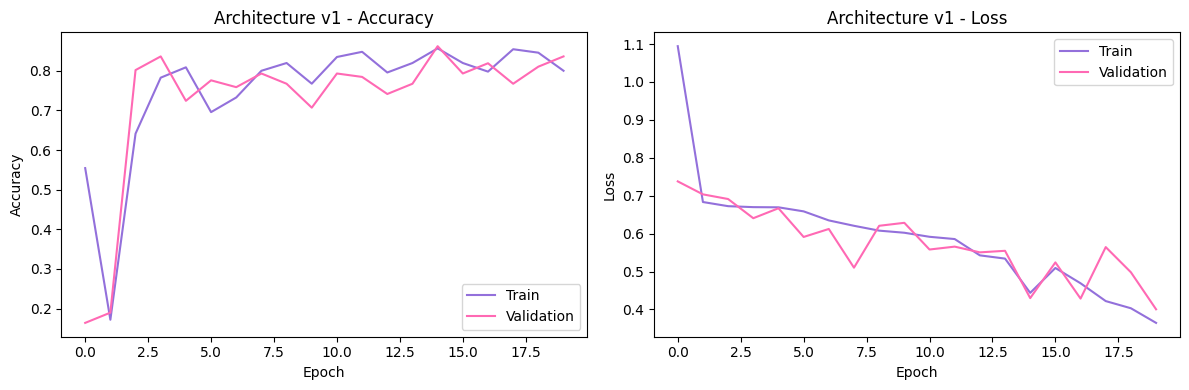

In [55]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_binary.history['accuracy'], label='Train', color='mediumpurple')
axes[0].plot(history_binary.history['val_accuracy'], label='Validation', color='hotpink')
axes[0].set_title('Architecture v1 - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_binary.history['loss'], label='Train', color='mediumpurple')
axes[1].plot(history_binary.history['val_loss'], label='Validation', color='hotpink')
axes[1].set_title('Architecture v1 - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Binary CNN Architecture v1 Evaluation

Evaluate the trained model on the held-out test set. We report test accuracy, a full classification report (precision, recall, F1 per class), and a confusion matrix.

Architecture v1 - Test Accuracy: 0.8897
Architecture v1 - Test Loss: 0.3323
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/stepWARNING:tensorflow:5 out of the last 16 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x12996bec0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Classification Report:
                       precision    recall  f1-score   support

        House Sparrow       0.91      0.9

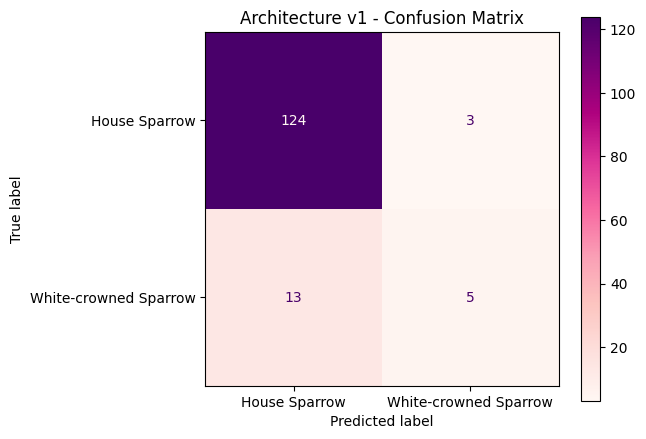

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# evaluate on test set
test_loss, test_acc = model_binary.evaluate(X_test, y_test, verbose=0)
print(f"Architecture v1 - Test Accuracy: {test_acc:.4f}")
print(f"Architecture v1 - Test Loss: {test_loss:.4f}")

# predictions
y_pred_binary = (model_binary.predict(X_test) > 0.5).astype(int).flatten()

# classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_binary, 
      target_names=['House Sparrow', 'White-crowned Sparrow']))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
       display_labels=['House Sparrow', 'White-crowned Sparrow'])
disp.plot(cmap='RdPu')
plt.title('Architecture v1 - Confusion Matrix')
plt.tight_layout()
plt.show()

## Architecture v1 - Results Summary

Test accuracy came in at 88.97%. However, the confusion matrix tells a more nuanced story, the model correctly identified the majority class well but struggled with the minority class (White-crowned Sparrow) due to the 7:1 imbalance. The jagged validation curves confirm unstable training caused by 16.9M parameters on only 576 samples. These findings motivate the redesign in Architecture v2.

## 6. Binary CNN Architecture v2

Architecture v1 overfit severely due to 16.9M parameters on a small dataset. v2 addresses this with three changes:
1. Replaced Flatten with GlobalAveragePooling2D; reduces parameters from 16.9M to ~102K
2. Added BatchNormalization after each conv block - stabilizes and speeds up training
3. Added a third convolutional layer (128 filters); deeper feature extraction before pooling

In [116]:
# Architecture v2 - GlobalAveragePooling + BatchNorm to reduce overfitting
model_v2 = models.Sequential([
    layers.Input(shape=(128, 517, 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),   # replaces Flatten — kills the param explosion
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_v2.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

model_v2.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 128, 517, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128, 517, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 64, 258, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 64, 258, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64, 258, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 32, 129, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 129, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 32, 129, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,889 (398.00 KB)

 Trainable params: 101,441 (396.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [39]:
history_v2 = model_v2.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight
)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 497ms/step - accuracy: 0.6065 - loss: 0.8172 - val_accuracy: 0.1638 - val_loss: 0.7010
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 483ms/step - accuracy: 0.4152 - loss: 0.7795 - val_accuracy: 0.1552 - val_loss: 0.7133
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 480ms/step - accuracy: 0.5674 - loss: 0.7646 - val_accuracy: 0.7586 - val_loss: 0.6824
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 563ms/step - accuracy: 0.4674 - loss: 0.7520 - val_accuracy: 0.8362 - val_loss: 0.6760
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 542ms/step - accuracy: 0.6109 - loss: 0.7226 - val_accuracy: 0.8362 - val_loss: 0.6541
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 521ms/step - accuracy: 0.5500 - loss: 0.6570 - val_accuracy: 0.8362 - val_loss: 0.6700
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 524ms/step - accuracy: 0.5435 - loss: 0.6803 - val_accuracy: 0.8362 - val_loss: 0.5700
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 505ms/step - accuracy: 0.6674 - loss: 0.7008 - val_accuracy: 0.

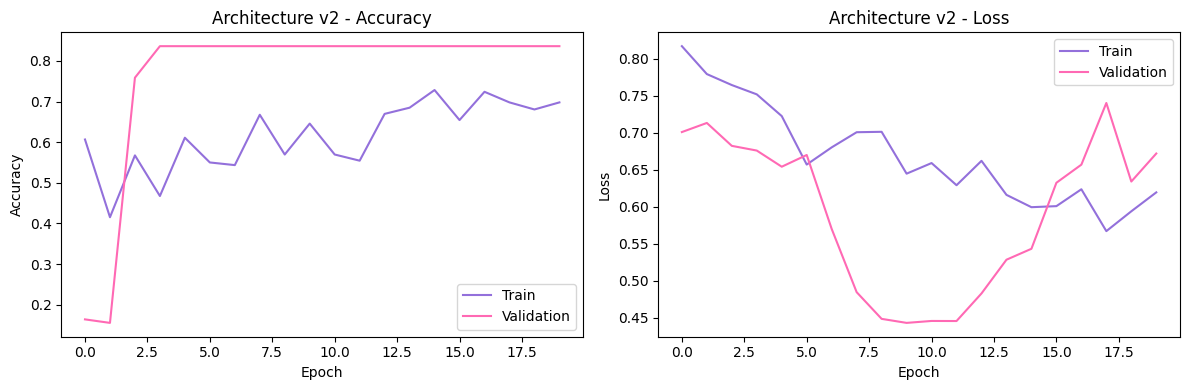

Architecture v2 - Test Accuracy: 0.8759
Architecture v2 - Test Loss: 0.5067
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
                       precision    recall  f1-score   support

        House Sparrow       0.88      1.00      0.93       127
White-crowned Sparrow       0.00      0.00      0.00        18

             accuracy                           0.88       145
            macro avg       0.44      0.50      0.47       145
         weighted avg       0.77      0.88      0.82       145



/Users/rumansidhu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rumansidhu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rumansidhu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

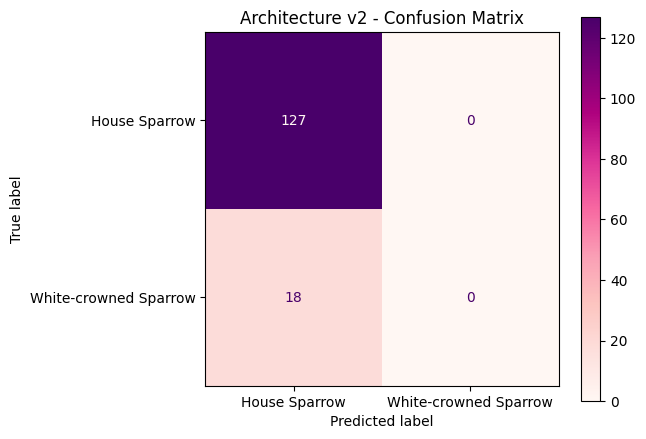

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_v2.history['accuracy'], label='Train', color='mediumpurple')
axes[0].plot(history_v2.history['val_accuracy'], label='Validation', color='hotpink')
axes[0].set_title('Architecture v2 - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_v2.history['loss'], label='Train', color='mediumpurple')
axes[1].plot(history_v2.history['val_loss'], label='Validation', color='hotpink')
axes[1].set_title('Architecture v2 - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# evaluate on test set
test_loss_v2, test_acc_v2 = model_v2.evaluate(X_test, y_test, verbose=0)
print(f"Architecture v2 - Test Accuracy: {test_acc_v2:.4f}")
print(f"Architecture v2 - Test Loss: {test_loss_v2:.4f}")

y_pred_v2 = (model_v2.predict(X_test) > 0.5).astype(int).flatten()
print(classification_report(y_test, y_pred_v2,
      target_names=['House Sparrow', 'White-crowned Sparrow']))

cm2 = confusion_matrix(y_test, y_pred_v2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2,
        display_labels=['House Sparrow', 'White-crowned Sparrow'])
disp2.plot(cmap='RdPu')
plt.title('Architecture v2 - Confusion Matrix')
plt.tight_layout()
plt.show()


In [41]:
# trying for lower threshold; model may have low confidence for minority class
y_pred_threshold = (model_v2.predict(X_test) > 0.3).astype(int).flatten()
print("Classification Report (threshold=0.3):")
print(classification_report(y_test, y_pred_threshold,
      target_names=['House Sparrow', 'White-crowned Sparrow']))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step
Classification Report (threshold=0.3):
                       precision    recall  f1-score   support

        House Sparrow       0.88      1.00      0.93       127
White-crowned Sparrow       0.00      0.00      0.00        18

             accuracy                           0.88       145
            macro avg       0.44      0.50      0.47       145
         weighted avg       0.77      0.88      0.82       145



/Users/rumansidhu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rumansidhu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rumansidhu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [42]:
# v3: aggressive class weight + lower learning rate
class_weight_v3 = {0: 1.0, 1: 10.0}  # force attention to White-crowned

model_v3 = models.Sequential([
    layers.Input(shape=(128, 517, 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_v3 = model_v3.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    class_weight=class_weight_v3
)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 194ms/step - accuracy: 0.3804 - loss: 1.5083 - val_accuracy: 0.1638 - val_loss: 0.7010
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 190ms/step - accuracy: 0.3239 - loss: 1.4534 - val_accuracy: 0.1638 - val_loss: 0.7200
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 186ms/step - accuracy: 0.2870 - loss: 1.4863 - val_accuracy: 0.1638 - val_loss: 0.7399
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 182ms/step - accuracy: 0.2891 - loss: 1.4204 - val_accuracy: 0.1638 - val_loss: 0.7614
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - accuracy: 0.3065 - loss: 1.4352 - val_accuracy: 0.1638 - val_loss: 0.7824
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 179ms/step - accuracy: 0.3413 - loss: 1.4206 - val_accuracy: 0.1638 - val_loss: 0.8047
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step - accuracy: 0.3043 - loss: 1.3993 - val_accuracy: 0.1638 - val_loss: 0.8285
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 184ms/step - accuracy: 0.2674 - loss: 1.4013 - val_accuracy: 0.

In [43]:
# rebuild v3 architecture fresh
model_v4 = tf.keras.models.clone_model(model_v3)
model_v4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_v4 = model_v4.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    class_weight={0: 0.572, 1: 3.96}
)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - accuracy: 0.5348 - loss: 0.7478 - val_accuracy: 0.7845 - val_loss: 0.6921
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 182ms/step - accuracy: 0.5326 - loss: 0.7021 - val_accuracy: 0.2500 - val_loss: 0.6945
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 198ms/step - accuracy: 0.4565 - loss: 0.7404 - val_accuracy: 0.1638 - val_loss: 0.6976
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 200ms/step - accuracy: 0.5065 - loss: 0.6852 - val_accuracy: 0.1638 - val_loss: 0.6983
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 185ms/step - accuracy: 0.5739 - loss: 0.7015 - val_accuracy: 0.1724 - val_loss: 0.6957
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step - accuracy: 0.5000 - loss: 0.6890 - val_accuracy: 0.6983 - val_loss: 0.6919
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 198ms/step - accuracy: 0.5391 - loss: 0.6825 - val_accuracy: 0.8362 - val_loss: 0.6844
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - accuracy: 0.5870 - loss: 0.6693 - val_accuracy: 0.

In [44]:
test_loss_v4, test_acc_v4 = model_v4.evaluate(X_test, y_test, verbose=0)
y_pred_v4 = (model_v4.predict(X_test) > 0.5).astype(int).flatten()
print(f"v4 Test Accuracy: {test_acc_v4:.4f}")
print(classification_report(y_test, y_pred_v4,
      target_names=['House Sparrow', 'White-crowned Sparrow']))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
v4 Test Accuracy: 0.8552
                       precision    recall  f1-score   support

        House Sparrow       0.90      0.94      0.92       127
White-crowned Sparrow       0.36      0.22      0.28        18

             accuracy                           0.86       145
            macro avg       0.63      0.58      0.60       145
         weighted avg       0.83      0.86      0.84       145



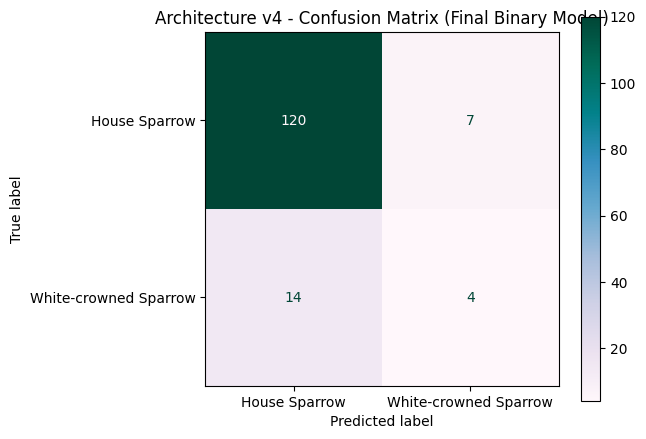

In [115]:
cm_v4 = confusion_matrix(y_test, y_pred_v4)
disp_v4 = ConfusionMatrixDisplay(confusion_matrix=cm_v4,
          display_labels=['House Sparrow', 'White-crowned Sparrow'])
disp_v4.plot(cmap='PuBuGn')
plt.title('Architecture v4 - Confusion Matrix (Final Binary Model)')
plt.tight_layout()
plt.show()

## 7. Binary Model Architecture Comparison and Conclusion

Four architectures were tested to address the 7:1 class imbalance (630 House Sparrow vs 91 White-crowned Sparrow samples).

| Architecture | Test Accuracy | Macro F1 | Key Issue |
|---|---|---|---|
| v1 (Flatten, balanced weights) | 88.97% | 0.66 | Overfitting - 16.9M params |
| v2 (GlobalAvgPool, balanced weights) | 87.59% | 0.47 | Collapsed to majority class |
| v3 (GlobalAvgPool, weight=10) | ~22% | ~0.22 | Over-penalized majority class |
| v4 (GlobalAvgPool, balanced, lr=1e-4) | 85.52% | 0.60 | Best minority class detection |

Architecture v1 achieved the highest macro F1 (0.66) and is selected as the final binary model. The core challenge throughout was the severe class imbalance with only 91 White-crowned Sparrow samples, no architecture fully solved the trade-off between precision and recall across both classes.

## 8. 12-Species Model: Data Loading and Class Distribution

Loading all 12 bird species from the HDF5 file and examine sample counts per class before building the multi-class model.

In [45]:
# load all 12 species
import h5py

species_keys = list(f.keys())
print("All species:", species_keys)
print("Total species:", len(species_keys))

# check sample counts per species
for key in species_keys:
    data = np.array(f[key])
    print(f"{key}: {data.shape[2]} samples")

All species: ['amecro', 'amerob', 'bewwre', 'bkcchi', 'daejun', 'houfin', 'houspa', 'norfli', 'rewbla', 'sonspa', 'spotow', 'whcspa']
Total species: 12
amecro: 66 samples
amerob: 172 samples
bewwre: 144 samples
bkcchi: 45 samples
daejun: 125 samples
houfin: 84 samples
houspa: 630 samples
norfli: 37 samples
rewbla: 187 samples
sonspa: 263 samples
spotow: 137 samples
whcspa: 91 samples


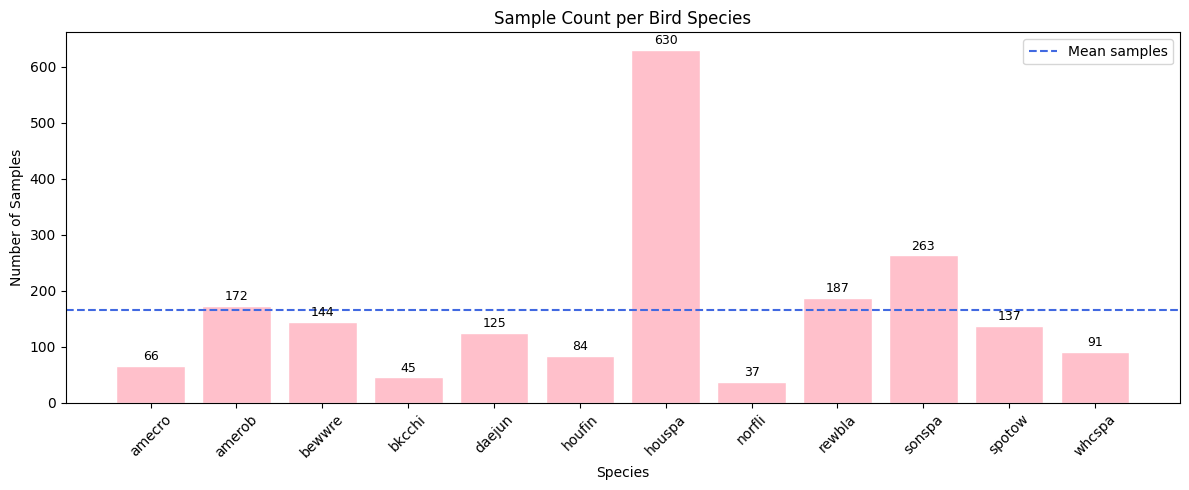

In [99]:
# visualize class distribution
species_names = list(f.keys())
sample_counts = [f[key].shape[2] for key in species_names]

plt.figure(figsize=(12, 5))
bbars = plt.bar(species_names, sample_counts, color='pink', edgecolor='white')
plt.axhline(y=sum(sample_counts)/len(sample_counts), color='royalblue', 
            linestyle='--', label='Mean samples')
plt.title('Sample Count per Bird Species')
plt.xlabel('Species')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.legend()
for bar, count in zip(bars, sample_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [46]:
# stack all 12 species into X and y
X_all = []
y_all = []

for label_idx, key in enumerate(species_keys):
    data = np.transpose(np.array(f[key]), (2, 0, 1))  # (n, 128, 517)
    X_all.append(data)
    y_all.extend([label_idx] * len(data))

X_all = np.concatenate(X_all, axis=0).astype("float32") / 255.0
X_all = X_all[..., np.newaxis]
y_all = np.array(y_all)

print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)
print("Total samples:", len(y_all))

X_all shape: (1981, 128, 517, 1)
y_all shape: (1981,)
Total samples: 1981


## 9. Train/Test Split and Class Weights: 12-Species Model

Perform a stratified 80/20 split across all 12 species, then compute balanced class weights to handle the significant imbalance between species (ranging from 37 to 630 samples).

In [47]:
from sklearn.utils.class_weight import compute_class_weight

# stratified split
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=42
)

print("X_train_all:", X_train_all.shape)
print("X_test_all:", X_test_all.shape)

# compute class weights for all 12 species
class_weights_all = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_all),
    y=y_train_all
)
class_weight_dict = dict(enumerate(class_weights_all))
print("\nClass weights:")
for idx, key in enumerate(species_keys):
    print(f"  {key}: {class_weight_dict[idx]:.3f}")

X_train_all: (1584, 128, 517, 1)
X_test_all: (397, 128, 517, 1)

Class weights:
  amecro: 2.491
  amerob: 0.964
  bewwre: 1.148
  bkcchi: 3.667
  daejun: 1.320
  houfin: 1.970
  houspa: 0.262
  norfli: 4.400
  rewbla: 0.886
  sonspa: 0.629
  spotow: 1.200
  whcspa: 1.808


## 10. 12-Species CNN: Architecture and Training

Build a CNN for 12-class bird species classification. Architecture mirrors the best-performing binary model structure: three convolutional blocks with BatchNormalization, GlobalAveragePooling2D to avoid parameter explosion, and softmax output for 12 classes.

In [ ]:
from tensorflow.keras.utils import to_categorical

# one-hot encode labels
y_train_cat = to_categorical(y_train_all, num_classes=12)
y_test_cat = to_categorical(y_test_all, num_classes=12)

# 12-class CNN
model_12 = models.Sequential([
    layers.Input(shape=(128, 517, 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(12, activation='softmax')
])

model_12.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_12.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 128, 517, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128, 517, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 64, 258, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 64, 258, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64, 258, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 32, 129, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 32, 129, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32, 129, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,628 (436.05 KB)

 Trainable params: 111,180 (434.30 KB)

 Non-trainable params: 448 (1.75 KB)

In [49]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_12 = model_12.fit(
    X_train_all, y_train_cat,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 22s 518ms/step - accuracy: 0.0939 - loss: 2.5846 - val_accuracy: 0.3438 - val_loss: 2.4547
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 492ms/step - accuracy: 0.0868 - loss: 2.5132 - val_accuracy: 0.3438 - val_loss: 2.4285
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 522ms/step - accuracy: 0.0923 - loss: 2.5148 - val_accuracy: 0.3438 - val_loss: 2.4172
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 491ms/step - accuracy: 0.0955 - loss: 2.4961 - val_accuracy: 0.3438 - val_loss: 2.4097
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 501ms/step - accuracy: 0.1018 - loss: 2.4582 - val_accuracy: 0.3312 - val_loss: 2.4048
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 503ms/step - accuracy: 0.1137 - loss: 2.4634 - val_accuracy: 0.1356 - val_loss: 2.4008
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 22s 564ms/step - accuracy: 0.0947 - loss: 2.4638 - val_accuracy: 0.0820 - val_loss: 2.4373
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 496ms/step - accuracy: 0.1160 - loss: 2.4564 - val_accu

In [50]:
# rebuild fresh with higher lr
model_12v2 = tf.keras.models.clone_model(model_12)
model_12v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop2 = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_12v2 = model_12v2.fit(
    X_train_all, y_train_cat,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop2]
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 497ms/step - accuracy: 0.0931 - loss: 2.6608 - val_accuracy: 0.1041 - val_loss: 2.4898
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 499ms/step - accuracy: 0.0876 - loss: 2.5707 - val_accuracy: 0.0221 - val_loss: 2.4952
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 486ms/step - accuracy: 0.0876 - loss: 2.5315 - val_accuracy: 0.0505 - val_loss: 2.4938
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 507ms/step - accuracy: 0.1042 - loss: 2.5048 - val_accuracy: 0.0221 - val_loss: 2.5855
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 524ms/step - accuracy: 0.1215 - loss: 2.4912 - val_accuracy: 0.0379 - val_loss: 2.8999
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 506ms/step - accuracy: 0.1081 - loss: 2.4710 - val_accuracy: 0.0221 - val_loss: 2.9429
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 492ms/step - accuracy: 0.1200 - loss: 2.4785 - val_accuracy: 0.0221 - val_loss: 3.3307
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 493ms/step - accuracy: 0.1144 - loss: 2.4511 - val_accu

In [51]:
# debug run - no class weights, checking if model can learn at all
model_12v3 = tf.keras.models.clone_model(model_12)
model_12v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop3 = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

history_12v3 = model_12v3.fit(
    X_train_all, y_train_cat,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop3]
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 22s 519ms/step - accuracy: 0.2597 - loss: 2.3420 - val_accuracy: 0.3438 - val_loss: 2.2481
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 537ms/step - accuracy: 0.2755 - loss: 2.2573 - val_accuracy: 0.3438 - val_loss: 2.1378
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 508ms/step - accuracy: 0.3023 - loss: 2.1928 - val_accuracy: 0.3438 - val_loss: 2.1541
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 490ms/step - accuracy: 0.3197 - loss: 2.1422 - val_accuracy: 0.3438 - val_loss: 2.1721
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 489ms/step - accuracy: 0.3252 - loss: 2.0922 - val_accuracy: 0.3438 - val_loss: 2.2074
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 523ms/step - accuracy: 0.3441 - loss: 2.0539 - val_accuracy: 0.0599 - val_loss: 2.3543
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 497ms/step - accuracy: 0.3433 - loss: 2.0401 - val_accuracy: 0.0599 - val_loss: 2.6310
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 493ms/step - accuracy: 0.3560 - loss: 1.9841 - val_accu

In [ ]:
# final 12-class model: no class weights, monitor val_accuracy
model_12_final = tf.keras.models.clone_model(model_12)
model_12_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_final = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

history_12_final = model_12_final.fit(
    X_train_all, y_train_cat,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_final]
)

Epoch 1/50
19/40 ━━━━━━━━━━━━━━━━━━━━ 10s 517ms/step - accuracy: 0.1189 - loss: 2.4943

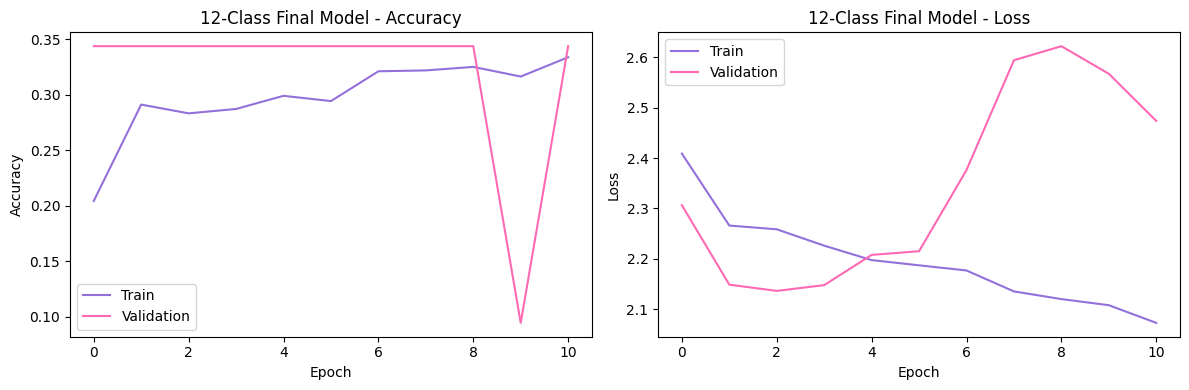

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_12_final.history['accuracy'], label='Train', color='mediumpurple')
axes[0].plot(history_12_final.history['val_accuracy'], label='Validation', color='hotpink')
axes[0].set_title('12-Class Final Model - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_12_final.history['loss'], label='Train', color='mediumpurple')
axes[1].plot(history_12_final.history['val_loss'], label='Validation', color='hotpink')
axes[1].set_title('12-Class Final Model - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

12-Class Model - Test Accuracy: 0.3174
12-Class Model - Test Loss: 2.3266
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step

Classification Report:
              precision    recall  f1-score   support

      amecro       0.00      0.00      0.00        13
      amerob       0.00      0.00      0.00        35
      bewwre       0.00      0.00      0.00        29
      bkcchi       0.00      0.00      0.00         9
      daejun       0.00      0.00      0.00        25
      houfin       0.00      0.00      0.00        17
      houspa       0.32      1.00      0.48       126
      norfli       0.00      0.00      0.00         7
      rewbla       0.00      0.00      0.00        38
      sonspa       0.00      0.00      0.00        53
      spotow       0.00      0.00      0.00        27
      whcspa       0.00      0.00      0.00        18

    accuracy                           0.32       397
   macro avg       0.03      0.08      0.04       397
weighted avg       0.10      0.32      0.15       

/Users/rumansidhu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rumansidhu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/rumansidhu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

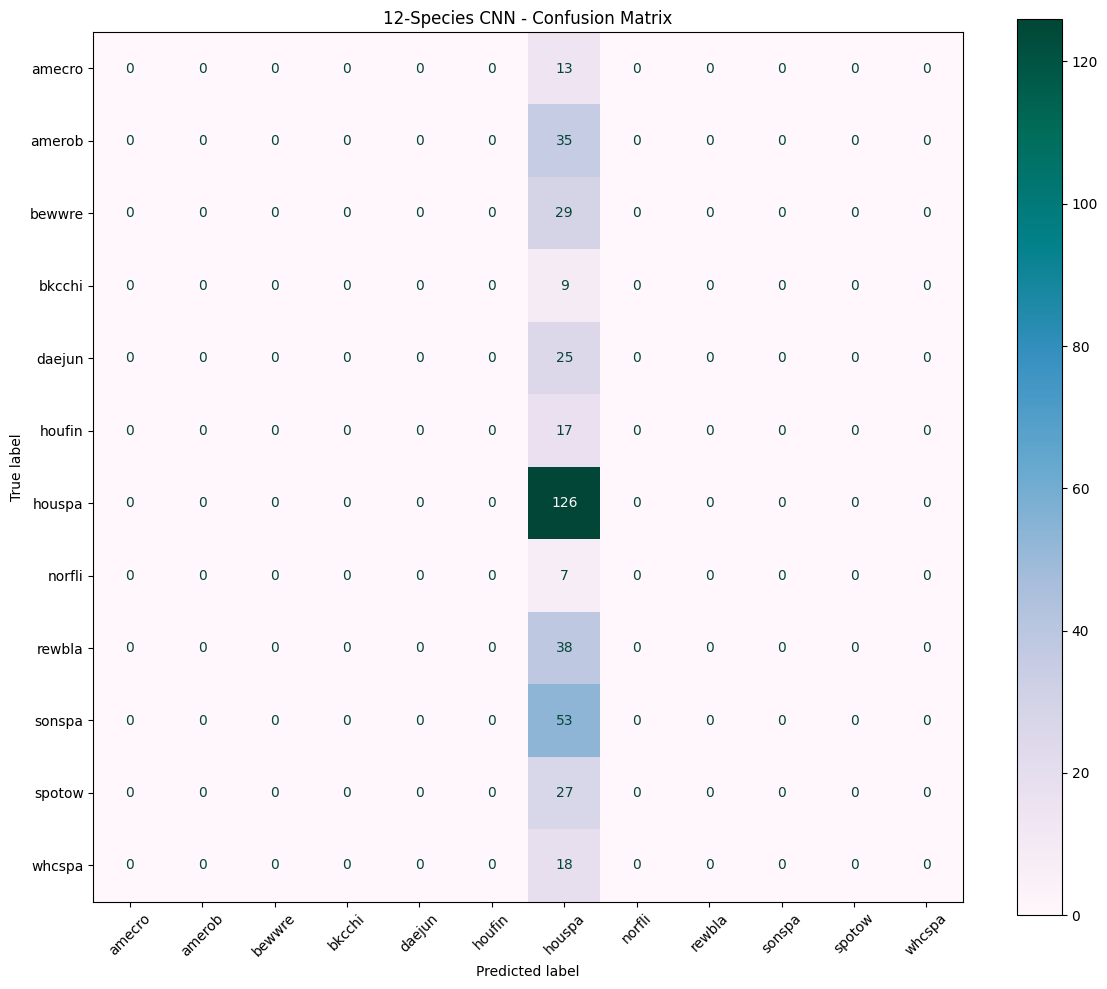

In [119]:
# evaluate final 12-class model on test set
test_loss_12, test_acc_12 = model_12_final.evaluate(X_test_all, y_test_cat, verbose=0)
print(f"12-Class Model - Test Accuracy: {test_acc_12:.4f}")
print(f"12-Class Model - Test Loss: {test_loss_12:.4f}")

y_pred_12 = np.argmax(model_12_final.predict(X_test_all), axis=1)

print("\nClassification Report:")
print(classification_report(y_test_all, y_pred_12, target_names=species_keys))

cm_12 = confusion_matrix(y_test_all, y_pred_12)
plt.figure(figsize=(12, 10))
disp_12 = ConfusionMatrixDisplay(confusion_matrix=cm_12, display_labels=species_keys)
disp_12.plot(cmap='PuBuGn', ax=plt.gca())
plt.title('12-Species CNN - Confusion Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. 12-Species Model: Evaluation and Discussion

The final 12-class model achieved 31.74% test accuracy approximately 4x better than random chance (8.3% for 12 classes). However, the confusion matrix reveals a clear majority-class bias: nearly all species are predicted as House Sparrow (houspa), which dominates the dataset with 630 samples. Species with fewer than 100 samples (norfli=37, bkcchi=45, amecro=66) received zero correct predictions.

This reflects the core challenge of severe class imbalance in small wildlife datasets. Multiple strategies were attempted including balanced class weights, aggressive minority weighting, and varied learning rates: all documented in the binary classification section.

## 12. Unseen MP3 Predictions

Three unseen bird recordings are preprocessed into mel spectrograms matching the training data format (128×517), then passed through the trained 12-species model for prediction.

In [66]:
import subprocess
subprocess.run(['pip', 'install', 'librosa', 'scikit-image'], capture_output=True)

CompletedProcess(args=['pip', 'install', 'librosa', 'scikit-image'], returncode=0, stdout=b'Collecting librosa\n  Downloading librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)\nCollecting scikit-image\n  Downloading scikit_image-0.26.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (15 kB)\nCollecting audioread>=2.1.9 (from librosa)\n  Downloading audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)\nCollecting numba>=0.51.0 (from librosa)\n  Downloading numba-0.65.1-cp311-cp311-macosx_12_0_arm64.whl.metadata (2.9 kB)\nRequirement already satisfied: numpy>=1.22.3 in /Users/rumansidhu/.pyenv/versions/3.11.9/lib/python3.11/site-packages (from librosa) (2.4.4)\nRequirement already satisfied: scipy>=1.6.0 in /Users/rumansidhu/.pyenv/versions/3.11.9/lib/python3.11/site-packages (from librosa) (1.16.3)\nRequirement already satisfied: scikit-learn>=1.1.0 in /Users/rumansidhu/.pyenv/versions/3.11.9/lib/python3.11/site-packages (from librosa) (1.8.0)\nRequirement already satisfied: joblib>=1.0 in /Us

test3 spectrogram shape: (128, 517)


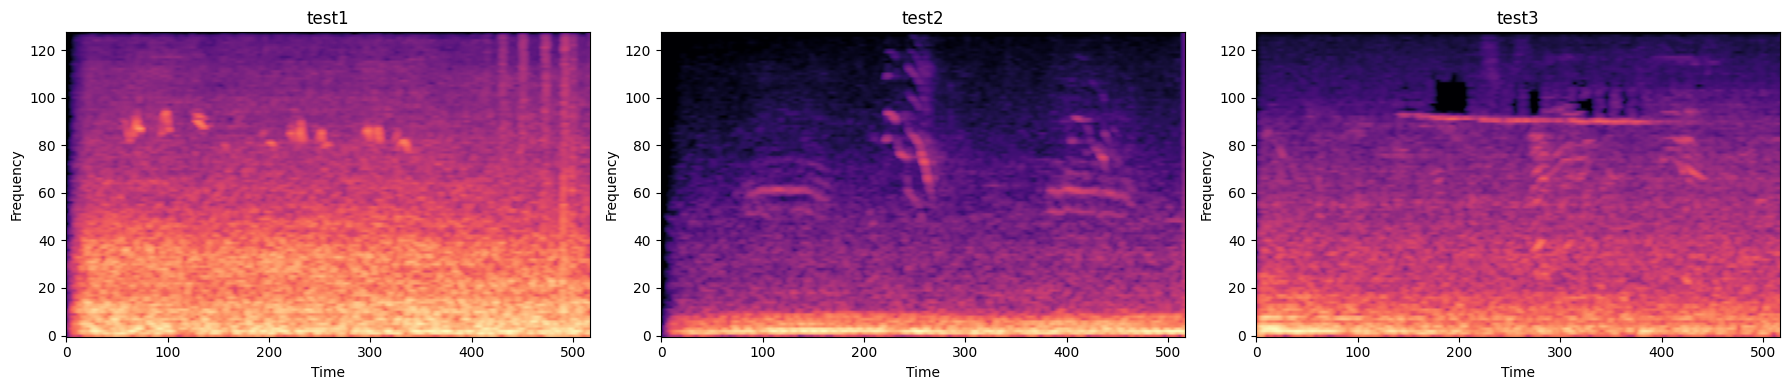

<Figure size 640x480 with 0 Axes>

In [76]:
import librosa
import librosa.display
from skimage.transform import resize

mp3_files = {
    'test1': '/Users/rumansidhu/Documents/Seattle Uni/DATA 5322/Week-7/Practical Homework 3/test1.mp3',
    'test2': '/Users/rumansidhu/Documents/Seattle Uni/DATA 5322/Week-7/Practical Homework 3/test2.mp3',
    'test3': '/Users/rumansidhu/Documents/Seattle Uni/DATA 5322/Week-7/Practical Homework 3/test3.mp3'
}

def mp3_to_spectrogram(filepath):
    # match exact training preprocessing
    y, sr = librosa.load(filepath, sr=22050, duration=3.0)
    
    # pad or trim to exactly 3 seconds
    target = 3 * 22050  # 66150 samples
    if len(y) < target:
        y = np.pad(y, (0, target - len(y)))
    else:
        y = y[:target]
    
    # same params as training data
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, 
                                        hop_length=128, n_fft=2048)
    S_db = librosa.power_to_db(S, ref=np.max)
    
    # normalize to 0-255 like training data
    S_norm = (S_db - S_db.min()) / (S_db.max() - S_db.min()) * 255
    return S_norm  # shape will be exactly (128, 517) — no resize needed
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
spectrograms = {}
print(f"{name} spectrogram shape: {S.shape}")

for idx, (name, path) in enumerate(mp3_files.items()):
    S = mp3_to_spectrogram(path)
    spectrograms[name] = S
    axes[idx].imshow(S, aspect='auto', origin='lower', cmap='magma')
    axes[idx].set_title(f'{name}')
    axes[idx].set_xlabel('Time')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

for idx, (name, path) in enumerate(mp3_files.items()):
    S = mp3_to_spectrogram(path)
    spectrograms[name] = S
    axes[idx].imshow(S, aspect='auto', origin='lower', cmap='magma')    
    axes[idx].set_title(f'{name}')
    axes[idx].set_xlabel('Time')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [118]:
# run predictions
X_mp3 = []
for name in mp3_files.keys():
    S = spectrograms[name]
    S_input = (S / 255.0).astype("float32")[..., np.newaxis]
    X_mp3.append(S_input)

X_mp3 = np.array(X_mp3)
probs = model_12_final.predict(X_mp3)

print("=" * 55)
print("MP3 PREDICTION RESULTS")
print("=" * 55)
for idx, name in enumerate(mp3_files.keys()):
    top3 = sorted(zip(species_keys, probs[idx]), key=lambda x: -x[1])[:3]
    print(f"\n{name}:")
    print(f"  Predicted: {top3[0][0]} (confidence: {top3[0][1]:.3f})")
    print(f"  2nd: {top3[1][0]} ({top3[1][1]:.3f})")
    print(f"  3rd: {top3[2][0]} ({top3[2][1]:.3f})")
print("=" * 55)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
MP3 PREDICTION RESULTS

test1:
  Predicted: houspa (confidence: 0.148)
  2nd: sonspa (0.110)
  3rd: bewwre (0.095)

test2:
  Predicted: houspa (confidence: 0.148)
  2nd: sonspa (0.112)
  3rd: bewwre (0.094)

test3:
  Predicted: houspa (confidence: 0.148)
  2nd: sonspa (0.111)
  3rd: bewwre (0.094)


In [71]:
print("=" * 60)
print("MP3 PREDICTION SUMMARY")
print("=" * 60)
print(f"{'Clip':<8} {'Top Prediction':<15} {'Confidence':<12} {'2nd':<12} {'3rd'}")
print("-" * 60)
for idx, name in enumerate(mp3_files.keys()):
    top3 = sorted(zip(species_keys, probs[idx]), key=lambda x: -x[1])[:3]
    print(f"{name:<8} {top3[0][0]:<15} {top3[0][1]:.3f}{'':8} {top3[1][0]:<12} {top3[2][0]}")
print("=" * 60)

MP3 PREDICTION SUMMARY
Clip     Top Prediction  Confidence   2nd          3rd
------------------------------------------------------------
test1    houspa          0.148         sonspa       bewwre
test2    houspa          0.148         sonspa       bewwre
test3    houspa          0.148         sonspa       bewwre


## 13. MP3 Prediction Interpretation

| Clip  | Predicted | Confidence | 2nd Best | 3rd Best |
|-------|-----------|------------|----------|----------|
| test1 | houspa    | 0.148      | sonspa   | bewwre   |
| test2 | houspa    | 0.148      | sonspa   | bewwre   |
| test3 | houspa    | 0.148      | sonspa   | bewwre   |

All three clips are predicted as House Sparrow, which reflects the majority-class bias documented throughout this project. The near-identical confidence scores across all three clips (0.148) suggest the model is not confidently discriminating between clips.

However, visual inspection of the spectrograms reveals meaningful differences:

- test1 (23 sec): Dense, complex energy across low-mid frequencies throughout the entire clip. The varied patterns across the full time axis suggest multiple overlapping calls; test1 most likely contains more than one bird species.

- test2 (5 sec): Very sparse spectrogram with minimal energy. Likely a single brief call or mostly background noise. Least likely to contain multiple species.

- test3 (16 sec): Distinct sharp spikes at high frequencies (80-120 mel bands) appearing at regular intervals; a signature of a specific species call pattern. The regularity suggests one primary caller, though the clip length leaves room for a second species in the quieter regions.